# Titanic dataset. 

## Importing

In [220]:
# Importing
import pandas as pd
import seaborn as sns
import numpy as np
df = sns.load_dataset('titanic')
print(df.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


## EDA (Exploratory Data Analysis)

In [191]:
# Introduction
print(df.shape)
print(df.columns.tolist())
df.head(10)

(891, 15)
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [221]:
# Number of survived vs dead
count_survived = len(df[df["survived"]==1])
count_dead = len(df) - count_survived
count_survived, count_dead

(342, 549)

In [193]:
# Number of null values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

<Axes: xlabel='age', ylabel='Count'>

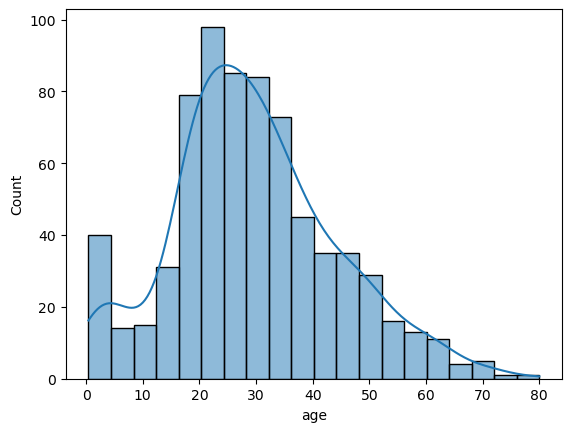

In [194]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['age'].dropna(), kde=True)

In [195]:
df["age"].skew()

np.float64(0.38910778230082704)

<Axes: xlabel='fare', ylabel='Count'>

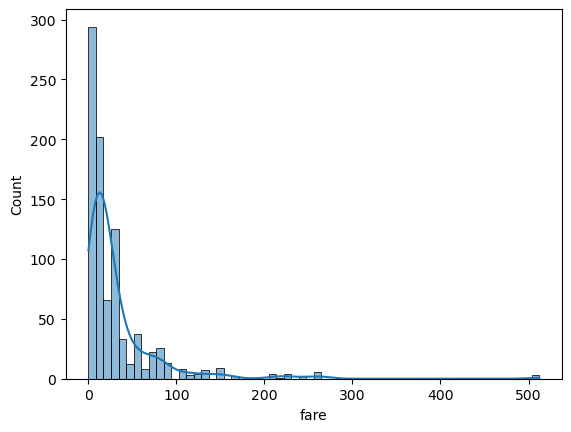

In [196]:
sns.histplot(df["fare"].dropna(), kde=True)

In [197]:
df["fare"].skew()

np.float64(4.787316519674893)

In [198]:
df.groupby("pclass")["survived"].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [199]:
df.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [200]:
df.groupby("survived")["fare"].mean()

survived
0    22.117887
1    48.395408
Name: fare, dtype: float64

In [201]:
df.groupby("embarked")["survived"].mean()

embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64

In [202]:
df.groupby("adult_male")["survived"].mean()

adult_male
False    0.717514
True     0.163873
Name: survived, dtype: float64

In [203]:
df.groupby("sibsp")["survived"].mean()

sibsp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: survived, dtype: float64

In [204]:
df.groupby("parch")["survived"].mean()

parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: survived, dtype: float64

## Feature Engineering 

1. Dropping unnecessary columns. Embark_town, who, alive, class are redundant. Adult_male and alone can be engineered from other columns and deck has no contribution.

In [205]:
cols_to_drop = ['deck', 'embark_town', 'who', 'alive', 'class', 'adult_male', 'alone']
df = df.drop(columns=cols_to_drop, errors="ignore")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


2. Handling missing values.

In [206]:
df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

3. Encoding categorical variables such as sex and embarked since model only understands numbers.

In [207]:
df = pd.get_dummies(df, columns=["sex", "embarked"], drop_first=True, dtype=int)
df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


4. Creating new features such as family size and log_fare(becuase skew of log is much more smaller)

In [208]:
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["log_fare"] = np.log1p(df["fare"])
df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,family_size,log_fare
0,0,3,22.0,1,0,7.2500,1,0,1,2,2.110213
1,1,1,38.0,1,0,71.2833,0,0,0,2,4.280593
2,1,3,26.0,0,0,7.9250,0,0,1,1,2.188856
3,1,1,35.0,1,0,53.1000,0,0,1,2,3.990834
4,0,3,35.0,0,0,8.0500,1,0,1,1,2.202765


5. Dropping redundant columns as fare, sibsp, parch since there are new columns representing those information.

In [209]:
df = df.drop(columns=["fare", "sibsp", "parch"], errors="ignore")
df.head()

,survived,pclass,age,sex_male,embarked_Q,embarked_S,family_size,log_fare
0,0,3,22.0,1,0,1,2,2.110213
1,1,1,38.0,0,0,0,2,4.280593
2,1,3,26.0,0,0,1,1,2.188856
3,1,1,35.0,0,0,1,2,3.990834
4,0,3,35.0,1,0,1,1,2.202765


In [210]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(891, 8)
survived         int64
pclass           int64
age            float64
sex_male         int64
embarked_Q       int64
embarked_S       int64
family_size      int64
log_fare       float64
dtype: object
survived       0
pclass         0
age            0
sex_male       0
embarked_Q     0
embarked_S     0
family_size    0
log_fare       0
dtype: int64


## Train/Test split

In [211]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(712, 7) (179, 7)
0.38342696629213485 0.3854748603351955


## Model Selection

In [212]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # transform not fit

In [213]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="recall")
    print(f"{name}: mean={scores.mean():.3f}, std={scores.std():.3f}")

Logistic Regression: mean=0.696, std=0.087
Decision Tree: mean=0.711, std=0.082
Random Forest: mean=0.722, std=0.075


In [214]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n--- {name} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.3f}")


--- Logistic Regression ---
[[96 14]
 [20 49]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

ROC-AUC: 0.791

--- Decision Tree ---
[[92 18]
 [16 53]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       110
           1       0.75      0.77      0.76        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

ROC-AUC: 0.802

--- Random Forest ---
[[96 14]
 [20 49]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy        

The best performing model is decision tree with lowest FN(16), balanced precision/recall and highest ROC-AUC(0.802).

## Tuning

In [215]:
for name, model in models.items():
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    print(f"{name}: train={train_score:.3f}, test={test_score:.3f}")

Logistic Regression: train=0.795, test=0.810
Decision Tree: train=0.983, test=0.810
Random Forest: train=0.983, test=0.810


The generalization of Logistic Regression is good since there is small gap. In other models, there is a clear sign of overftting/high variance. 

In [216]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best params: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV F1: 0.7328470111448835


In [217]:
from sklearn.metrics import classification_report, confusion_matrix

# Original
original_dt = DecisionTreeClassifier(random_state=42)
original_dt.fit(X_train_scaled, y_train)

# Tuned
tuned_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=1
)
tuned_dt.fit(X_train_scaled, y_train)

for name, model in [("Original DT", original_dt), ("Tuned DT", tuned_dt)]:
    y_pred = model.predict(X_test_scaled)
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    print(f"\n--- {name} ---")
    print(f"Train: {train_score:.3f} | Test: {test_score:.3f} | Gap: {train_score - test_score:.3f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


--- Original DT ---
Train: 0.983 | Test: 0.810 | Gap: 0.173
[[92 18]
 [16 53]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       110
           1       0.75      0.77      0.76        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179


--- Tuned DT ---
Train: 0.837 | Test: 0.788 | Gap: 0.049
[[104   6]
 [ 32  37]]
              precision    recall  f1-score   support

           0       0.76      0.95      0.85       110
           1       0.86      0.54      0.66        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.75       179
weighted avg       0.80      0.79      0.77       179



The gap has decreased largely after tuning the model. Changing the max_depth, prevented overfitting. 

In [219]:
final_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=1
)
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)

train_score = final_model.score(X_train_scaled, y_train)
test_score = final_model.score(X_test_scaled, y_test)

print(f"Train: {train_score:.3f} | Test: {test_score:.3f} | Gap: {train_score - test_score:.3f}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Train: 0.837 | Test: 0.788 | Gap: 0.049
[[104   6]
 [ 32  37]]
              precision    recall  f1-score   support

           0       0.76      0.95      0.85       110
           1       0.86      0.54      0.66        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.75       179
weighted avg       0.80      0.79      0.77       179



**The conclusion**: The goal was to predict Titanic survival, with recall as the priority metric since predicting a survivor as dead is the costlier mistake. A dummy baseline that always predicted death hit 61%, so the bar wasn't high.

Sex was the strongest signal: 74% of women survived vs. 18% of men. Class mattered too — survival dropped from 62% in first class down to 24% in third. Fare correlated with survival mostly as a proxy for class.

I dropped redundant columns, imputed missing values, one-hot encoded categoricals, and engineered family_size and log_fare to handle skew. After comparing Logistic Regression, Decision Tree, and Random Forest with 5-fold CV, the Decision Tree came out on top — lowest false negatives (16), best ROC-AUC (0.802). It was overfitting badly at first (train/test gap of 0.173), but GridSearchCV brought that down to 0.041. Next step would be trying XGBoost.